# Import libraries

In [1]:
import numpy as np
from skimage.util import view_as_windows
import matplotlib.pyplot as plt

from utils_experiments import scale_to_range, unscale_from_range

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


2025-07-19 22:03:14.586104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-19 22:03:14.682919: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-19 22:03:14.708101: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-19 22:03:14.869054: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-19 22:03:16.318747: W tensorflow/compiler/tf2

# Load Data

In [2]:
seis_mature= np.load('../2024_tesis_maestria/data/data_decatur/processed/seismic_mature_block.npy')
phi_mature = np.load('../2024_tesis_maestria/data/data_decatur/processed/porosity_mature_block.npy')

seis_exploration = np.load('../2024_tesis_maestria/data/data_decatur/processed/seismic_exploration_block.npy')
phi_exploration = np.load('../2024_tesis_maestria/data/data_decatur/processed/porosity_exploration_block.npy')

well_porosity_data = np.load('../2024_tesis_maestria/data/data_decatur/processed/well_porosity.npy')

phi_mature[phi_mature<0] = 0
phi_exploration[phi_exploration<0] = 0


# Scale Data

In [3]:
seis_mature = scale_to_range(seis_mature)
phi_mature = scale_to_range(phi_mature)

seis_exploration = scale_to_range(seis_exploration)
phi_exploration = scale_to_range(phi_exploration)

true_well_data = scale_to_range(well_porosity_data)



In [4]:
true_well_data = true_well_data.reshape(2,86,1)
true_well_data.shape

(2, 86, 1)

In [5]:
seis_mature.shape, seis_exploration.shape

((143, 841, 86), (143, 370, 86))

# Add Padding to patch

In [6]:
pad_mature = ((0, 17), (0, 23), (0, 10))
pad_exploration = ((0, 17), (0, 14), (0, 10))

# 3. Apply the padding
# 'constant' mode pads with a constant value, which defaults to 0.
seis_mature = np.pad(seis_mature, pad_width=pad_mature, mode='constant')
phi_mature = np.pad(phi_mature, pad_width=pad_mature, mode='constant')

seis_exploration = np.pad(seis_exploration, pad_width=pad_exploration, mode='constant')
phi_exploration = np.pad(phi_exploration, pad_width=pad_exploration, mode='constant')

# 4. Check the new shape
print(f"Padded shape TRAIN:   {seis_mature.shape}")
print(f"Padded shape TEST:   {seis_exploration.shape}")

Padded shape TRAIN:   (160, 864, 96)
Padded shape TEST:   (160, 384, 96)


# Add mask to the images

In [7]:
# 2. Crea una máscara inicial llena de UNOS con la forma original
# Esto marca todos los pixeles de datos reales como 1.
mascara_de_unos = np.ones((143, 841, 86), dtype=np.int8)

# 3. Aplica el padding usando el modo 'constant'. Por defecto, rellena con 0.
# Esto crea los bordes de ceros automáticamente.
mascara_padded = np.pad(mascara_de_unos, pad_width=pad_mature, mode='constant')

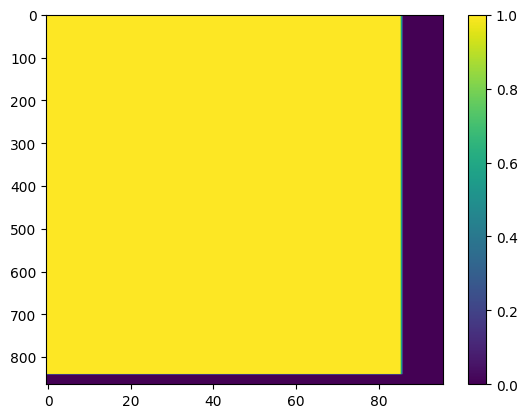

In [8]:
plt.imshow(mascara_padded[0, :, :], aspect='auto')
plt.colorbar()

In [9]:
def process_and_add_mask(data_volume, mask_volume, axis_order):
    """
    Reshapes a data volume and combines it with a mask.
    
    Args:
        data_volume (np.array): The 3D seismic data.
        mask_volume (np.array): The 3D mask data.
        axis_order (tuple): The desired new order of axes (e.g., (2, 0, 1)).
        
    Returns:
        np.array: The final data with shape (# images, height, width, 2).
    """
    # 1. Reshape the data and mask volumes
    # This turns the volume into a stack of 2D images
    data_reshaped = np.transpose(data_volume, axes=axis_order)
    mask_reshaped = np.transpose(mask_volume, axes=axis_order)
    
    # 2. Add a new 'channel' axis at the end of both arrays
    # Shape becomes (# images, height, width, 1)
    data_with_channel = data_reshaped[..., np.newaxis]
    mask_with_channel = mask_reshaped[..., np.newaxis]
    
    # 3. Concatenate along the new channel axis (axis=-1)
    # This stacks the data and the mask together
    final_dataset = np.concatenate([data_with_channel, mask_with_channel], axis=-1)
    
    return final_dataset


# Process the TRAIN set for this orientation
X_z = process_and_add_mask(seis_mature, mascara_padded, axis_order=(2, 0, 1))
print(f"Orientation 1 TRAIN shape: {X_z.shape}") # Expected: (96, 160, 864, 2)

X_il = process_and_add_mask(seis_mature, mascara_padded, axis_order=(0, 1, 2))
print(f"Orientation 2 TRAIN shape: {X_il.shape}") # Expected: (160, 864, 96, 2)

# Process the TRAIN set for this orientation
X_xl = process_and_add_mask(seis_mature, mascara_padded, axis_order=(1, 0, 2))
print(f"Orientation 3 TRAIN shape: {X_z.shape}") # Expected: (864, 160, 96, 2)


# Process the TRAIN set for this orientation
Y_z = process_and_add_mask(phi_mature, mascara_padded, axis_order=(2, 0, 1))
print(f"Orientation 1 TRAIN shape: {Y_z.shape}") # Expected: (96, 160, 864, 2)

Y_il = process_and_add_mask(phi_mature, mascara_padded, axis_order=(0, 1, 2))
print(f"Orientation 2 TRAIN shape: {Y_il.shape}") # Expected: (160, 864, 96, 2)

# Process the TRAIN set for this orientation
Y_xl = process_and_add_mask(phi_mature, mascara_padded, axis_order=(1, 0, 2))
print(f"Orientation 3 TRAIN shape: {Y_z.shape}") # Expected: (864, 160, 96, 2)

Orientation 1 TRAIN shape: (96, 160, 864, 2)
Orientation 2 TRAIN shape: (160, 864, 96, 2)
Orientation 3 TRAIN shape: (96, 160, 864, 2)
Orientation 1 TRAIN shape: (96, 160, 864, 2)
Orientation 2 TRAIN shape: (160, 864, 96, 2)
Orientation 3 TRAIN shape: (96, 160, 864, 2)


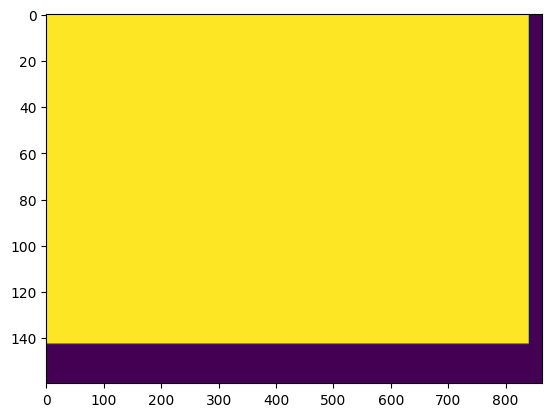

In [10]:
plt.imshow(X_il[:, :, 0, 1], aspect='auto')

# Creación de Patches

In [11]:
def extract_patches(image_stack, patch_size, stride):
    """Extrae parches 2D de un stack de imágenes (N, H, W)."""
    patch_h, patch_w = patch_size
    stride_h, stride_w = stride
    
    patches = []
    for i in range(image_stack.shape[0]):
        for y in range(0, image_stack.shape[1] - patch_h + 1, stride_h):
            for x in range(0, image_stack.shape[2] - patch_w + 1, stride_w):
                patches.append(image_stack[i, y:y+patch_h, x:x+patch_w])
    return np.array(patches)


In [12]:
PATCH_SIZE = (64, 64)
STRIDE = (32, 32)

In [13]:
patches_train_X_z = extract_patches(X_z, PATCH_SIZE, STRIDE)
n_patches_X_z = len(patches_train_X_z)

patches_train_X_il = extract_patches(X_il, PATCH_SIZE, STRIDE)
n_patches_X_il = len(patches_train_X_il)

patches_train_X_xl = extract_patches(X_xl, PATCH_SIZE, STRIDE)
n_patches_X_xl = len(patches_train_X_xl)

print(f"Parches de SEIS MATURE extraídos: IL={n_patches_X_il}, XL={n_patches_X_xl}, Z={n_patches_X_z}")

# Combinar todos los parches para una predicción eficiente
X_train_patches = np.concatenate([patches_train_X_il, patches_train_X_xl, patches_train_X_z], axis=0)

patches_train_Y_z = extract_patches(Y_z, PATCH_SIZE, STRIDE)
n_patches_Y_z = len(patches_train_Y_z)

patches_train_Y_il = extract_patches(Y_il, PATCH_SIZE, STRIDE)
n_patches_Y_il = len(patches_train_Y_il)

patches_train_Y_xl = extract_patches(Y_xl, PATCH_SIZE, STRIDE)
n_patches_Y_xl = len(patches_train_Y_xl)

print(f"Parches de SEIS MATURE extraídos: IL={n_patches_X_il}, XL={n_patches_X_xl}, Z={n_patches_X_z}")

# Combinar todos los parches para una predicción eficiente
Y_train_patches = np.concatenate([patches_train_Y_il, patches_train_Y_xl, patches_train_Y_z], axis=0)

Parches de SEIS MATURE extraídos: IL=8320, XL=6912, Z=9984
Parches de SEIS MATURE extraídos: IL=8320, XL=6912, Z=9984


In [14]:
Y_train_patches.shape

(25216, 64, 64, 2)

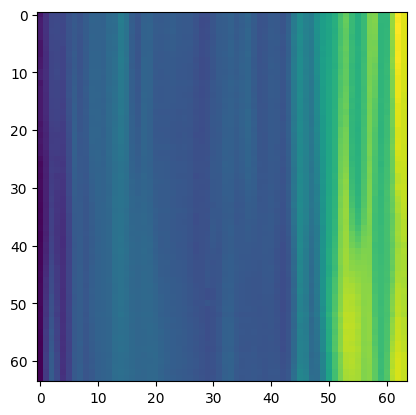

In [15]:
plt.imshow(Y_train_patches[0, :, :,0])

# Reordenar para darle variabilidad

In [16]:
# 1. Obten el número total de parches
n_samples = X_train_patches.shape[0]

# 2. Crea un array de índices y barájalo
indices_train = np.arange(n_samples)
np.random.shuffle(indices_train)

# 3. Usa los índices barajados para reordenar ambos arrays
X_train_shuffled = X_train_patches[indices_train]
Y_train_shuffled = Y_train_patches[indices_train]

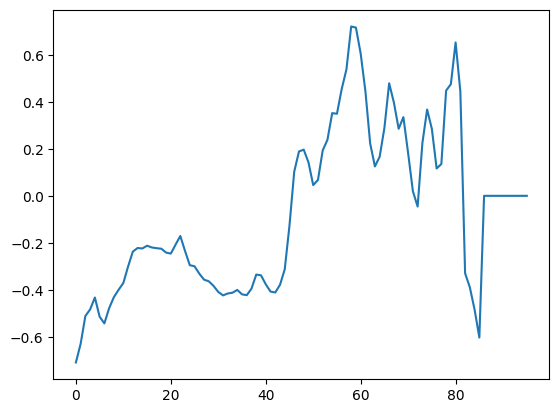

In [17]:
plt.plot(phi_mature[37, 783, :]) # VW2

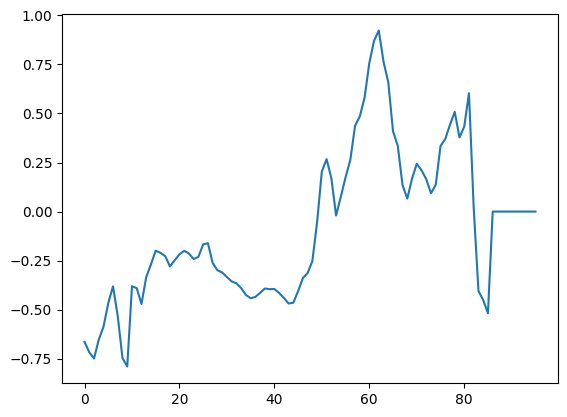

In [18]:
plt.plot(phi_mature[69, 338, :]) #CCS2

# Prueba encontrar indices

In [19]:
def encontrar_indices_relevantes(coord_objetivo, dim_total, tamano_parche, stride_paso):
    """Encuentra los índices de los patches que cubren una coordenada específica."""
    indices_relevantes = []
    # Itera sobre cada posible índice de parche en esta dimensión
    for i in range(0, (dim_total - tamano_parche) // stride_paso + 1):
        inicio_parche = i * stride_paso
        fin_parche = inicio_parche + tamano_parche
        # Si la coordenada está dentro de la ventana del parche, guardamos el índice
        if inicio_parche <= coord_objetivo < fin_parche:
            indices_relevantes.append(i)
    return indices_relevantes

In [20]:
Y_il_temp = Y_il[:, :, :, 0]

In [21]:
h_pad, w_pad, _ =Y_il_temp.shape
coords_vw2 = (37, 783)

In [22]:
indices_inline_relevantes = encontrar_indices_relevantes(
    coords_vw2[0], h_pad, PATCH_SIZE[0], STRIDE[0])

indices_xline_relevantes = encontrar_indices_relevantes(
    coords_vw2[1], w_pad, PATCH_SIZE[1], STRIDE[1])

In [ ]:
acumulador = np.zeros_like(Y_il_temp)
mapa_normalizacion = np.zeros_like(Y_il_temp)

print(f"\nReconstruyendo solo con los {len(indices_inline_relevantes) * len(indices_xline_relevantes)} patches necesarios...")

for i in indices_inline_relevantes:
    for j in indices_xline_relevantes:
        # Calculamos la esquina superior izquierda del parche
        y = i * STRIDE[0]
        x = j * STRIDE[1]
        
        # Extraemos el parche de los datos acolchados
        patch = Y_il_temp[y:y+PATCH_SIZE[0], x:x+PATCH_SIZE[1], :]
        # Acumulamos y normalizamos como antes
        acumulador[y:y+PATCH_SIZE[0], x:x+PATCH_SIZE[1], :] += patch
        mapa_normalizacion[y:y+PATCH_SIZE[0], x:x+PATCH_SIZE[1], :] += 1

datos_reconstruidos_padded = np.divide(
    acumulador, mapa_normalizacion, where=mapa_normalizacion != 0)

# ===================================================================
# 4. Verificación
# ===================================================================
shape_original = (143, 841, 86)
traza_original_real = Y_il_temp[coords_vw2[0], coords_vw2[1], :]

h_orig, w_orig, _ = shape_original
datos_reconstruidos_original = datos_reconstruidos_padded[:h_orig, :w_orig, :]
traza_reconstruida = datos_reconstruidos_original[coords_vw2[0], coords_vw2[1], :]

es_correcto = np.allclose(traza_original_real, traza_reconstruida)
print(f"\n¿La reconstrucción optimizada de la traza es correcta?: {es_correcto} ✅")


Reconstruyendo solo con los 4 patches necesarios...
(64, 64, 96)
(64, 64, 96)
(64, 64, 96)
(64, 64, 96)

¿La reconstrucción optimizada de la traza es correcta?: True ✅


In [ ]:
plt.plot(traza_original_real, label='Original', color='red', linewidth=1, alpha=0.5)
plt.plot(traza_reconstruida, label='Reconstruida', color='blue', linewidth=1, alpha=0.5, linestyle='--')
plt.legend(loc='upper right')
plt.show()

# Red Neuronal

In [ ]:
def unet_2d_builder_for_patches(input_shape=(64, 64, 2)):
    """
    U-Net 2D simplificada y corregida para funcionar con parches de entrada
    de (32, 32, 1). Se eliminaron las capas de Padding y Cropping innecesarias.
    """
    inputs = tf.keras.layers.Input(shape=input_shape)

    # --- ENCODER (SENDA DE CONTRACCIÓN) ---
    # La entrada de 32x32 se dividirá limpiamente.

    # Bloque 1: 32x32 -> 16x16
    c1 = tf.keras.layers.Conv2D(16, (5, 5), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(16, (5, 5), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    # Bloque 2: 16x16 -> 8x8
    c2 = tf.keras.layers.Conv2D(32, (10, 10), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(32, (10, 10), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    # --- BOTTLENECK (FONDO DE LA U) ---
    # 8x8
    b = tf.keras.layers.Conv2D(64, (15, 15), activation='relu', padding='same')(p2)
    b = tf.keras.layers.Conv2D(64, (15, 15), activation='relu', padding='same')(b)

    # --- DECODER (SENDA DE EXPANSIÓN) ---

    # Bloque 3: 8x8 -> 16x16
    u1 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(b)
    # Ahora las formas coinciden: u1 (16x16) y c2 (16x16)
    u1 = tf.keras.layers.concatenate([u1, c2])
    c3 = tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same')(u1)
    c3 = tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same')(c3)

    # Bloque 4: 16x16 -> 32x32
    u2 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c3)
    # Ahora las formas coinciden: u2 (32x32) y c1 (32x32)
    u2 = tf.keras.layers.concatenate([u2, c1])
    c4 = tf.keras.layers.Conv2D(16, (5, 5), activation='relu', padding='same')(u2)
    c4 = tf.keras.layers.Conv2D(16, (5, 5), activation='relu', padding='same')(c4)

    # --- CAPA DE SALIDA ---
    # La salida tendrá la misma forma que la entrada del parche.
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='linear')(c4)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

In [ ]:
# 1. Build the model with your input shape
my_unet_model = unet_2d_builder_for_patches(input_shape=(64, 64, 2))

# 2. Print summary to check the architecture
my_unet_model.summary()

# 3. Compile the model
my_unet_model.compile(optimizer='adam', loss='mse')

# 4. Train the model (assuming X_train and y_train are prepared)
history = my_unet_model.fit(X_train_shuffled, Y_train_shuffled, batch_size=64, epochs=50)

In [ ]:
plt.plot(range(1,51), history.history['loss'], label='Training loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
def reconstruct_from_patches(patches, target_shape, patch_size, stride):
    """
    Reconstruye un stack de imágenes a partir de parches 2D, promediando
    las regiones solapadas para evitar artefactos.
    """
    n_images, h, w = target_shape
    patch_h, patch_w = patch_size
    stride_h, stride_w = stride

    reconstructed_stack = np.zeros(target_shape)
    count_map = np.zeros(target_shape)
    patch_idx = 0

    for i in range(n_images):
        for y in range(0, h - patch_h + 1, stride_h):
            for x in range(0, w - patch_w + 1, stride_w):
                if patch_idx < len(patches):
                    reconstructed_stack[i, y:y+patch_h, x:x+patch_w] += patches[patch_idx]
                    count_map[i, y:y+patch_h, x:x+patch_w] += 1
                    patch_idx += 1
    
    # Evitar división por cero
    count_map[count_map == 0] = 1
    return reconstructed_stack / count_map

In [ ]:
X_test_patches.shape 

In [ ]:
# --- 1. Preparación de los Datos de Test ---

# Parámetros (deben ser los mismos que usaste para entrenar)
PATCH_SIZE = (64, 64)
STRIDE = (32, 32) # Asumiendo un stride, ajústalo si es diferente

# Asumimos que `cubo_sismico_test` tiene la forma (inline, crossline, depth)
# Y que ya tiene el padding necesario, igual que en el entrenamiento.
original_shape = seis_exploration.shape 

# Vista Inline: (inline, depth, crossline)
s_il = seis_exploration.transpose(0, 2, 1)
patches_test_il = extract_patches(s_il, PATCH_SIZE, STRIDE)
n_patches_il = len(patches_test_il)

# Vista Crossline: (crossline, depth, inline)
s_xl = seis_exploration.transpose(1, 2, 0)
patches_test_xl = extract_patches(s_xl, PATCH_SIZE, STRIDE)
n_patches_xl = len(patches_test_xl)

# Vista Z-Slice: (depth, inline, crossline)
s_z = seis_exploration.transpose(2, 0, 1)
patches_test_z = extract_patches(s_z, PATCH_SIZE, STRIDE)
n_patches_z = len(patches_test_z)

print(f"Parches de test extraídos: IL={n_patches_il}, XL={n_patches_xl}, Z={n_patches_z}")

# Combinar todos los parches para una predicción eficiente
all_test_patches = np.concatenate([patches_test_il, patches_test_xl, patches_test_z], axis=0)
all_test_patches = np.expand_dims(all_test_patches, axis=-1) # Añadir canal

In [ ]:
predicted_patches_all = my_unet_model.predict(all_test_patches)

predicted_patches_all = predicted_patches_all.squeeze() # Quitar dimensión de canal


In [ ]:
print("Separando las predicciones por orientación original...")
idx_start = 0


predicted_patches_il = predicted_patches_all[idx_start : idx_start + n_patches_il]
idx_start += n_patches_il

predicted_patches_xl = predicted_patches_all[idx_start : idx_start + n_patches_xl]
idx_start += n_patches_xl

predicted_patches_z = predicted_patches_all[idx_start : idx_start + n_patches_z]

In [ ]:
print("\nReconstruyendo cubo 3D desde la vista INLINE...")
reconstructed_il_T = reconstruct_from_patches(predicted_patches_il, s_il.shape, PATCH_SIZE, STRIDE)
# Deshacer la transposición: (inline, depth, crossline) -> (inline, crossline, depth)
reconstructed_il = reconstructed_il_T.transpose(0, 2, 1)

print("Reconstruyendo cubo 3D desde la vista CROSSLINE...")
reconstructed_xl_T = reconstruct_from_patches(predicted_patches_xl, s_xl.shape, PATCH_SIZE, STRIDE)
# Deshacer la transposición: (crossline, depth, inline) -> (inline, crossline, depth)
reconstructed_xl = reconstructed_xl_T.transpose(2, 0, 1)

print("Reconstruyendo cubo 3D desde la vista Z-SLICE...")
reconstructed_z_T = reconstruct_from_patches(predicted_patches_z, s_z.shape, PATCH_SIZE, STRIDE)
# Deshacer la transposición: (depth, inline, crossline) -> (inline, crossline, depth)
reconstructed_z = reconstructed_z_T.transpose(1, 2, 0)

# Antes de promediar, asegúrate de que todos los cubos tengan la forma original (sin padding)
# Si añadiste padding, necesitarás recortarlos.
reconstructed_il = reconstructed_il[:original_shape[0], :original_shape[1], :original_shape[2]]
reconstructed_xl = reconstructed_xl[:original_shape[0], :original_shape[1], :original_shape[2]]
reconstructed_z = reconstructed_z[:original_shape[0], :original_shape[1], :original_shape[2]]


print("\nPromediando los tres cubos reconstruidos...")
final_porosity_cube = np.mean([reconstructed_il, reconstructed_xl, reconstructed_z], axis=0)

print("\n--- ¡Proceso de predicción y ensamblado completado! ---")
print(f"Forma del cubo de porosidad final: {final_porosity_cube.shape}")

In [ ]:
final_porosity_cube.shape

In [ ]:
plt.imshow(final_porosity_cube[:,80,:].T, aspect='auto', cmap='jet')

In [ ]:
plt.imshow(final_porosity_cube[43,:,:].T, aspect='auto', cmap='jet')